# Video MVP — YOLOv8 Semantic Segmentation Inference

**Purpose**: Run the trained YOLOv8 segmentation model on a full surgical video and produce
an annotated output video with per-frame colour-coded segmentation overlays.

**Prerequisites**: Run `notebooks/yolov8_seg_training.ipynb` first to generate `results/train/weights/best.pt`.

**GPU**: Automatically uses CUDA if available; falls back to CPU (slower but functional).

In [8]:
import os, json
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Video, display, HTML

# ─── CONFIGURATION ────────────────────────────────────────────────────────────
# Resolve paths consistently whether Jupyter starts in the repository root or notebooks/.
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (cwd, *cwd.parents) if (p / 'videos').is_dir() and (p / 'notebooks').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError(f'Could not locate the project root from: {cwd}')

VIDEO_PATH   = PROJECT_ROOT / 'videos/video_12/video_left.avi'
MODEL_PATH   = PROJECT_ROOT / 'notebooks/runs/segment/results/train/weights/best.pt'
OUTPUT_PATH  = PROJECT_ROOT / 'notebooks/runs/segment/results/video_mvp_output.mp4'
CONF_THRESH  = 0.25

# Auto-detect device — GPU if available, CPU otherwise (constitution Principle IV)
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}  |  CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('Running on CPU — inference will be slower but fully functional.')

# Class names and BGR colours for overlay
CLASS_NAMES = {
    0: 'background',
    1: 'bipolar_forceps',
    2: 'prograsp_forceps',
    3: 'large_needle_driver',
    4: 'vessel_sealer',
    5: 'grasping_retractor',
    6: 'monopolar_curved_scissors',
    7: 'ultrasound_probe',
    8: 'suction_instrument',
    9: 'suture_needle',
}

# RGB colours for matplotlib display
CLASS_COLORS_RGB = {
    0: (0,   0,   0),
    1: (255, 0,   0),
    2: (0,   255, 0),
    3: (0,   0,   255),
    4: (255, 255, 0),
    5: (255, 0,   255),
    6: (0,   255, 255),
    7: (128, 0,   255),
    8: (255, 128, 0),
    9: (0,   128, 255),
}

# BGR for OpenCV overlay
CLASS_COLORS_BGR = {k: (v[2], v[1], v[0]) for k, v in CLASS_COLORS_RGB.items()}

Using device: 0  |  CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


Model loaded from: E:\Alireza\surgery\notebooks\runs\segment\results\train\weights\best.pt
Classes: {0: 'background', 1: 'bipolar_forceps', 2: 'prograsp_forceps', 3: 'large_needle_driver', 4: 'vessel_sealer', 5: 'grasping_retractor', 6: 'monopolar_curved_scissors', 7: 'ultrasound_probe', 8: 'suction_instrument', 9: 'suture_needle'}


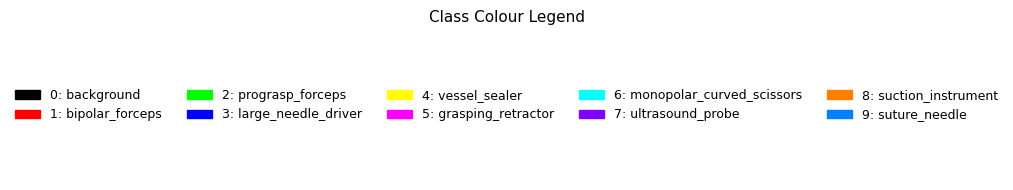

In [9]:
# Cell 2 — Load model and display colour legend
model_path = Path(MODEL_PATH)
if not model_path.exists():
    raise FileNotFoundError(
        f'Checkpoint not found: {model_path}\n'
        'Run notebooks/yolov8_seg_training.ipynb first.'
    )

model = YOLO(str(model_path))
print(f'Model loaded from: {model_path}')
print(f'Classes: {model.names}')

# Render colour legend
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')
patches = [
    mpatches.Patch(color=np.array(CLASS_COLORS_RGB[i])/255, label=f'{i}: {CLASS_NAMES[i]}')
    for i in range(10)
]
ax.legend(handles=patches, loc='center', ncol=5, fontsize=9, frameon=False)
plt.title('Class Colour Legend', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 3 — Frame-by-frame inference with segmentation overlay

def results_to_semantic(result, h, w):
    """Convert YOLOv8 instance results to per-pixel semantic class map."""
    canvas = np.zeros((h, w), dtype=np.uint8)
    if result.masks is None or len(result.masks.data) == 0:
        return canvas
    confs   = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    masks   = result.masks.data.cpu().numpy()
    for i in np.argsort(confs):  # lowest conf first; highest wins last
        m = cv2.resize(masks[i], (w, h))
        canvas[m > 0.5] = classes[i]
    return canvas

def overlay_semantic_mask(frame_bgr, semantic_map, alpha=0.5):
    """Blend colour-coded semantic mask onto BGR frame."""
    overlay = frame_bgr.copy()
    for cls_id, color_bgr in CLASS_COLORS_BGR.items():
        if cls_id == 0:
            continue  # skip background
        mask = semantic_map == cls_id
        if mask.any():
            overlay[mask] = (
                np.array(frame_bgr[mask], dtype=float) * (1 - alpha)
                + np.array(color_bgr) * alpha
            ).astype(np.uint8)
    return overlay

def draw_legend(frame_bgr, class_names, colors_bgr, font_scale=0.45, thickness=1):
    """Draw a class legend in the top-left corner of the frame."""
    x0, y0, dy = 10, 20, 18
    for cls_id, name in class_names.items():
        if cls_id == 0:
            continue
        y = y0 + (cls_id - 1) * dy
        color = colors_bgr[cls_id]
        cv2.rectangle(frame_bgr, (x0, y - 11), (x0 + 12, y + 1), color, -1)
        cv2.putText(frame_bgr, name, (x0 + 16, y),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness)
    return frame_bgr

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise FileNotFoundError(f'Could not open input video: {Path(VIDEO_PATH).resolve()}')

fps    = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
if fps <= 0 or width <= 0 or height <= 0:
    cap.release()
    raise RuntimeError(
        f'Invalid video metadata: {width}x{height}, {fps:.1f} FPS. Input: {VIDEO_PATH}'
    )
print(f'Video: {VIDEO_PATH}')
print(f'Resolution: {width}x{height}  |  FPS: {fps:.1f}  |  Frames: {n_frames}')

Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(OUTPUT_PATH), fourcc, fps, (width, height))
if not writer.isOpened():
    cap.release()
    raise RuntimeError(f'Could not open output video writer: {OUTPUT_PATH}')

sample_indices = set(np.linspace(0, max(n_frames - 1, 0), 6, dtype=int))
sample_frames = []
processed = 0

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        results = model.predict(frame, device=DEVICE, conf=CONF_THRESH, verbose=False)
        r = results[0]

        sem_map  = results_to_semantic(r, height, width)
        annotated = overlay_semantic_mask(frame, sem_map, alpha=0.5)
        annotated = draw_legend(annotated, CLASS_NAMES, CLASS_COLORS_BGR)
        writer.write(annotated)
        if processed in sample_indices:
            sample_frames.append((processed, annotated.copy()))

        processed += 1
        if processed % 100 == 0:
            print(f'  Processed {processed}/{n_frames} frames...')
finally:
    cap.release()
    writer.release()

if processed == 0:
    raise RuntimeError(f'No frames were decoded from: {VIDEO_PATH}')
print(f'[OK] Inference complete - {processed} frames processed.')

Video: E:\Alireza\surgery\videos\video_12\video_left.avi
Resolution: 1920x1080  |  FPS: 60.0  |  Frames: 7871
  Processed 100/7871 frames...
  Processed 200/7871 frames...
  Processed 300/7871 frames...
  Processed 400/7871 frames...
  Processed 500/7871 frames...
  Processed 600/7871 frames...
  Processed 700/7871 frames...
  Processed 800/7871 frames...


In [ ]:
# Cell 4 — Verify the annotated video written during inference
if not Path(OUTPUT_PATH).is_file() or Path(OUTPUT_PATH).stat().st_size == 0:
    raise RuntimeError(f'Output video was not written correctly: {OUTPUT_PATH}')

size_mb = Path(OUTPUT_PATH).stat().st_size / (1024 * 1024)
print(f'[OK] Video saved: {OUTPUT_PATH}  ({size_mb:.1f} MB)')

In [ ]:
# Cell 5 — Display output video inline (or show frame samples if too large)
MAX_INLINE_MB = 50
size_mb = Path(OUTPUT_PATH).stat().st_size / (1024 * 1024)

if size_mb <= MAX_INLINE_MB:
    print(f'Displaying inline ({size_mb:.1f} MB)...')
    display(Video(str(OUTPUT_PATH), embed=True, width=900))
else:
    print(f'Video is {size_mb:.1f} MB — too large for inline display.')
    print(f'Open it directly: {Path(OUTPUT_PATH).resolve()}')

    # Show the sample frames retained during streaming inference
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    for ax in axes.ravel():
        ax.axis('off')
    for ax, (idx, frame) in zip(axes.ravel(), sample_frames):
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Frame {idx}')
    plt.suptitle('Sample annotated frames from output video')
    plt.tight_layout()
    plt.show()